## Temel Bileşen Regresyonu (Model)

*Veri Seti Hikayesi: Veri seti basketbolcuların yaptığı isabetli basket atışları, asistleri, deneyim süreleri gibi bilgileri içeriyor.*

In [1]:
import pandas as pd
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    str    
 14  Division   263 non-null    str    
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    str    
dtypes: float64(1), int64(16), 

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AtBat,263.0,403.642586,147.307209,19.0,282.5,413.0,526.0,687.0
Hits,263.0,107.828897,45.125326,1.0,71.5,103.0,141.5,238.0
HmRun,263.0,11.619772,8.757108,0.0,5.0,9.0,18.0,40.0
Runs,263.0,54.745247,25.539816,0.0,33.5,52.0,73.0,130.0
RBI,263.0,51.486692,25.882714,0.0,30.0,47.0,71.0,121.0
Walks,263.0,41.114068,21.718056,0.0,23.0,37.0,57.0,105.0
Years,263.0,7.311787,4.793616,1.0,4.0,6.0,10.0,24.0
CAtBat,263.0,2657.543726,2286.582929,19.0,842.5,1931.0,3890.5,14053.0
CHits,263.0,722.186312,648.199644,4.0,212.0,516.0,1054.0,4256.0
CHmRun,263.0,69.239544,82.197581,0.0,15.0,40.0,92.5,548.0


In [4]:
#one-hot encoding

In [5]:
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
dms.head()

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
5,1,0,0,1,1,0


In [6]:
y = df["Salary"]

In [7]:
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X_.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0


In [8]:
#dummy değişken tuzağını ortadan kaldırmak

In [9]:
#train için hazır hale gelen bağımsız değişkenler
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,1,1,1
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,0,1,0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,1,0,1
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,1,0,1
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,0,1,0


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42)

print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape) 
print("y_test", y_test.shape)
training = df.copy()
print("training", training.shape)

X_train (197, 19)
X_test (66, 19)
y_train (197,)
y_test (66,)
training (263, 20)


In [12]:
#Ölçeklendirme ve boyut indirgeme

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

pca = PCA()

In [14]:
#model oluşturma ve boyut indirgeme

In [15]:
X_reduced_train = pca.fit_transform(scale(X_train))

In [16]:
#bir gözlemdeki bütün bileşenler

In [17]:
X_reduced_train[0:1,:]

array([[-2.49569913e+00,  3.37762397e-01,  7.06391950e-01,
        -1.32791025e+00, -8.21824333e-01, -6.62790677e-01,
         6.56764789e-01,  3.68093279e-02, -2.03665105e-01,
         1.76134815e-01, -9.20131987e-02,  2.40129020e-01,
         3.60473661e-03, -3.41246327e-02, -4.32799605e-02,
         1.02996923e-01, -3.70733348e-03, -1.37933445e-03,
         6.63814471e-03]])

In [18]:
import numpy as np

In [19]:
np.cumsum(np.round(pca.explained_variance_ratio_, decimals = 4)*100)[0:10]

array([38.18, 59.88, 70.88, 78.88, 84.18, 88.45, 92.05, 94.86, 96.34,
       97.28])

*Yukarıda ne yaptık ? ilk 10 değişkenin varyans değerlerini bulduk. Yani 1.değişken toplam değişkenliğin(varyansın) yüzde 38'ini açıklayabiliyor. 10.değişken diğer 9 değişken ile birlikte bütün değişkenliğin %97'si gibi çok büyük bir kısmını açıklayabiliyor.*

*Orijinal veri setindeki 19 değişkenin tamamına ihtiyaç duymadan 10 değişken ile varyansın %97'sini açıklayabiliyoruz. İşte temel bileşen analizinin temel mantığı budur. Veri setini daha az bileşen ile içerdiği bilgi bakımından neredeyse aynı şekilde temsil edebiliyoruz. Bu şekilde uygun bileşen sayısını bulup bu bileşenler üzerine model kurabiliyoruz.*

In [20]:
#model kurulumu

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lm = LinearRegression()

In [23]:
pcr_model = lm.fit(X_reduced_train, y_train)

In [24]:
pcr_model.intercept_

np.float64(543.4834416243655)

In [25]:
pcr_model.coef_

array([ 111.13977427,   29.34209502,   26.29799759,  -38.47549852,
        -56.9200785 ,   54.44779423,  -40.77493384,  -23.72746012,
          9.31198164,   13.02031672,   45.58357748,   31.97791627,
        -18.93930958, -115.60940171,  -24.00382778,  415.70806202,
        449.51779543, -563.07375399, -302.53718462])

## Tahmin

In [26]:
y_pred = pcr_model.predict(X_reduced_train)

In [27]:
y_pred[0:5]

array([377.44484744, 802.19452124, 495.60987745, 112.53177731,
       426.21613066])

In [28]:
#train seti için rmse hesabı

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
np.sqrt(mean_squared_error(y_train, y_pred))

np.float64(289.3292825564976)

In [31]:
df["Salary"].mean()

np.float64(535.9258821292775)

In [32]:
#r2 değeri hesaplama

In [33]:
r2_score(y_train,y_pred)

0.577007525041018

In [34]:
#test hatası

In [35]:
#test veri setinde boyut indirgeme

In [36]:
pca2 = PCA()

In [37]:
X_reduced_test = pca2.fit_transform(scale(X_test))

In [38]:
y_pred = pcr_model.predict(X_reduced_test)

In [39]:
#test için rmse hesabı

In [40]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(400.2799477144971)

## Model Tuning

*Modeli indirgenmiş bütün bileşenleri kullanarak eğittik. Burada modelin hiperparametresi bileşen sayısıdır. Farklı bileşen sayıları deneyerek en optimum bileşenli modeli bulabiliriz. Burada bunu yapacağız.*

*Bütün bileşenleri kullanarak oluşturduğumuz modelin test hatasını yeniden bir gözlemleyelim:*

In [41]:
lm = LinearRegression()
pcr_model = lm.fit(X_reduced_train[:, 0:10], y_train)
y_pred = pcr_model.predict(X_reduced_test[:, 0:10])
print(np.sqrt(mean_squared_error(y_test, y_pred)))

409.8007965147624


*Aslında yukarıdaki kodda sürekli bileşen sayısını değiştirdim ve farklı test hataları elde ettim. Bu şekilde gelişigüzel deneme-yanılma yöntemiyle model tuning yapılmaz. Her bir bileşen için bir model oluşturacağız. Daha sonra bu oluşturduğumuz her bir model için k katlı cross validation değeri elde edeceğiz. Daha sonra hata değerlerini hesaplayıp bir listeye atacağız. Liste içerisinde hangi bileşen sayısının bize en iyi hata oranını vermiş olacağını göreceğiz. Bu işleme **Brute Force** da deniyor.*

In [42]:
from sklearn import model_selection

In [43]:
cv_10 = model_selection.KFold(n_splits = 10,
                              shuffle = True,
                              random_state = 1)

In [44]:
lm = LinearRegression()

In [45]:
RMSE = []

In [46]:
for i in np.arange(1, X_reduced_train.shape[1] + 1):
    
    score = np.sqrt(-1*model_selection.cross_val_score(lm,
                                                       X_reduced_train[:, :i],
                                                       y_train.to_numpy().ravel(),
                                                       cv = cv_10,
                                                       scoring = "neg_mean_squared_error").mean())
    RMSE.append(score)


In [47]:
import matplotlib.pyplot as plt

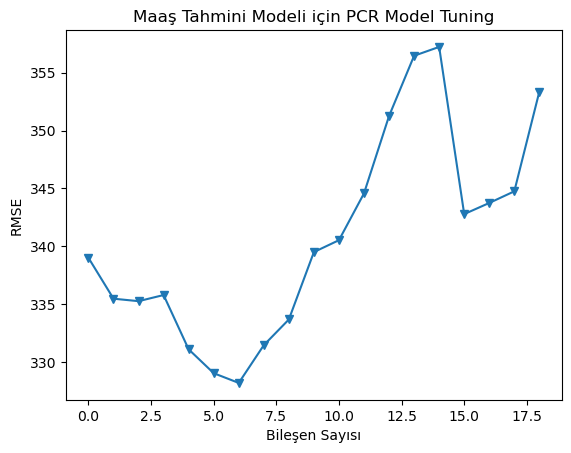

In [48]:
plt.plot(RMSE, "-v")
plt.xlabel('Bileşen Sayısı')
plt.ylabel('RMSE')
plt.title('Maaş Tahmini Modeli için PCR Model Tuning');

*Yukarıdaki grafikten en az RMSE değerinin bileşen sayısı 6 olduğu zaman olduğunu görüyoruz. Bu işlemi cross validation yöntemi ile eğitim setini kullanarak yaptık. Şimdi optimum bileşen değeri ile final modeli oluşturalım.* 

In [49]:
lm = LinearRegression()

In [50]:
pcr_model = lm.fit(X_reduced_train[:, 0:6], y_train)

In [51]:
y_pred = pcr_model.predict(X_reduced_train[:, 0:6])

In [52]:
#train seti için rmse hesabı

In [53]:
print(np.sqrt(mean_squared_error(y_train, y_pred)))

308.8265983094501


In [54]:
pcr_model = lm.fit(X_reduced_test[:, 0:6], y_test)

In [55]:
y_pred = pcr_model.predict(X_reduced_test[:, 0:6])

In [56]:
#train seti için rmse hesabı

In [57]:
print(np.sqrt(mean_squared_error(y_test, y_pred)))

378.517983714103


## ÖZET

*İlk önce ilkel bir train ve test hatası hesaplaması yaptık. Elde ettiğimiz bu train ve test hatalarını daha doğru değerlendirebilmenin yolu da cross validation ile incelemektir. Model tuning aşamasında cross validation ile en iyi parametre değerini buluyoruz. Daha sonra bu en optimum bileşen değeri ile final modelimizi oluşturuyoruz. Yine en optimum parametre değeri ile oluşturduğumuz modelin train ve test hata hesaplamalarını yapıyoruz. Aslında en uygun parametre değerini bulduktan sonra train hatası ile ilgilenmemize gerek yok ama biz yine de baktık. Çünkü zaten en optimum parametre ile model oluşturduk. En son en optimum model ile en optimum test hatasını elde etmiş oluyoruz.* 